<a href="https://colab.research.google.com/github/khouloud472/-Waste-Management-Recycling-Platform/blob/main/LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**LSTM** : Classification de signaux ECG avec un réseau LSTM

À partir d’un segment d’ECG (140 points), prédire la classe du battement cardiaque :

Classe 1 : battement normal
Classes 2–5 : types de battements anormaux
Entrée = série temporelle de longueur 140
Sortie = un label parmi {1,2,3,4,5}

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.utils import to_categorical


***Charger les fichiers .txt***

In [2]:
train_df = pd.read_csv("ECG5000_TRAIN.txt", sep=r"\s+", header=None)
test_df  = pd.read_csv("ECG5000_TEST.txt",  sep=r"\s+", header=None)

print(train_df.shape, test_df.shape)
train_df.head()


(500, 141) (4500, 141)


,0,1,2,3,4,5,6,7,8,9,...,131,132,133,134,135,136,137,138,139,140
0,1.0,-0.112522,-2.827204,-3.773897,-4.349751,-4.376041,-3.474986,-2.181408,-1.818286,-1.250522,...,0.160348,0.792168,0.933541,0.796958,0.578621,0.257740,0.228077,0.123431,0.925286,0.193137
1,1.0,-1.100878,-3.996840,-4.285843,-4.506579,-4.022377,-3.234368,-1.566126,-0.992258,-0.754680,...,0.560327,0.538356,0.656881,0.787490,0.724046,0.555784,0.476333,0.773820,1.119621,-1.436250
2,1.0,-0.567088,-2.593450,-3.874230,-4.584095,-4.187449,-3.151462,-1.742940,-1.490659,-1.183580,...,1.284825,0.886073,0.531452,0.311377,-0.021919,-0.713683,-0.532197,0.321097,0.904227,-0.421797
3,1.0,0.490473,-1.914407,-3.616364,-4.318823,-4.268016,-3.881110,-2.993280,-1.671131,-1.333884,...,0.491173,0.350816,0.499111,0.600345,0.842069,0.952074,0.990133,1.086798,1.403011,-0.383564
4,1.0,0.800232,-0.874252,-2.384761,-3.973292,-4.338224,-3.802422,-2.534510,-1.783423,-1.594450,...,0.966606,1.148884,0.958434,1.059025,1.371682,1.277392,0.960304,0.971020,1.614392,1.421456


pd.read_csv() : C’est la fonction de pandas qui lit un fichier texte et le transforme en DataFrame (tableau à 2 dimensions).
"ECG5000_TRAIN.txt" → charge le fichier d’entraînement
"ECG5000_TEST.txt" → charge le fichier de test


train_df et test_df deviennent deux tableaux contenant :
colonne 0 → la classe (1, 2, 3, 4, 5)
colonnes 1 à 140 → les valeurs du signal ECG pour ce battement

**Séparer features (X) et labels (y)**

In [3]:
X_train = train_df.iloc[:, 1:].values  # signaux (140 points)
y_train = train_df.iloc[:, 0].values   # labels (1..5)

X_test  = test_df.iloc[:, 1:].values
y_test  = test_df.iloc[:, 0].values


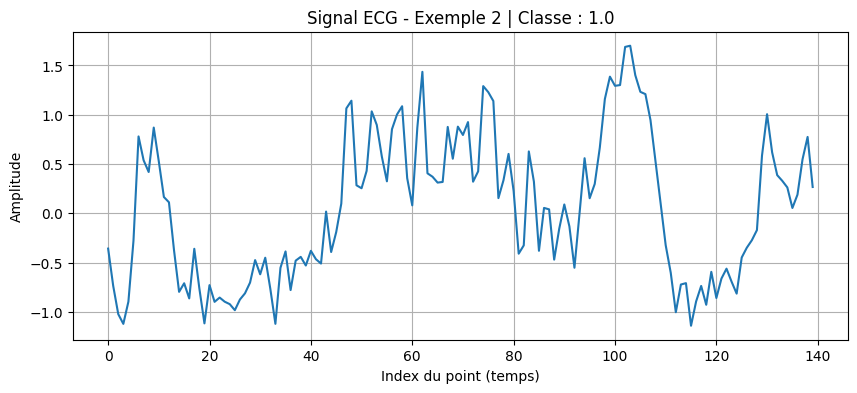

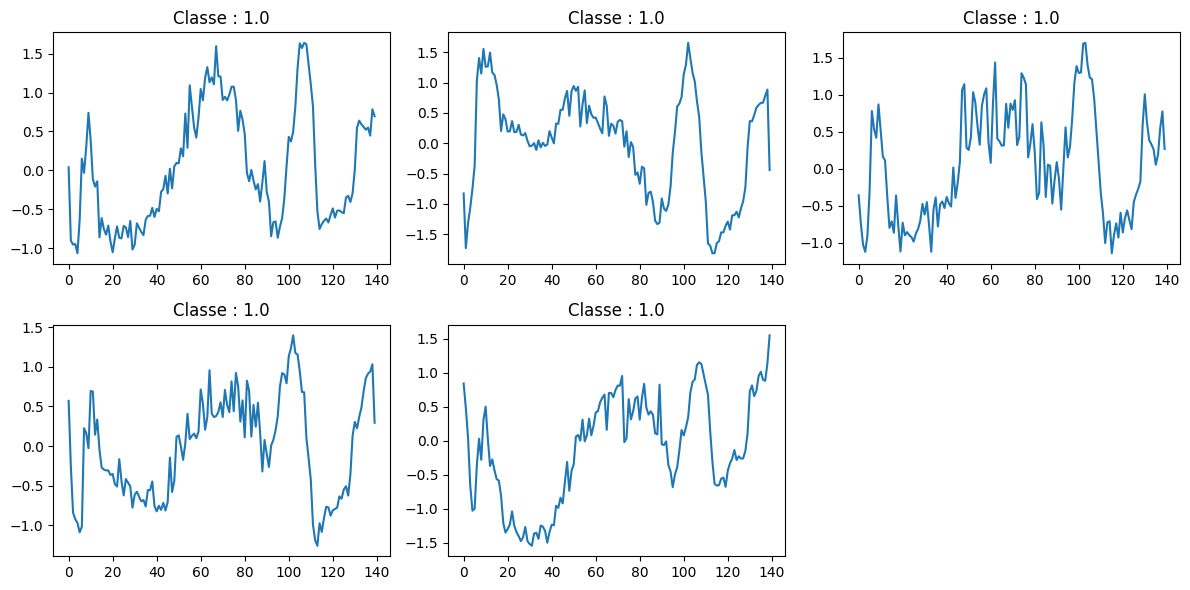

In [15]:
import matplotlib.pyplot as plt

index = 2  # changer cet indice pour voir d'autres battements

plt.figure(figsize=(10,4))
plt.plot(X_train[index])
plt.title(f"Signal ECG - Exemple {index} | Classe : {y_train[index]}")
plt.xlabel("Index du point (temps)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

plt.figure(figsize=(12,6))

for i in range(5):  # afficher 5 exemples
    plt.subplot(2, 3, i+1)
    plt.plot(X_train[i])
    plt.title(f"Classe : {y_train[i]}")
    plt.tight_layout()

plt.show()


Tableau train_df (et test_df) est structuré comme ceci :
Colonne	| Contenu
0	      | Label (classe du battement : 1, 2, 3, 4, 5)
1 à 140	| Valeurs du signal ECG

Donc il faut séparer :
y = colonne 0 (label à prédire)
X = colonnes 1 à 140 (signal ECG brut)

Que signifie iloc[:, 1:] ?
: → toutes les lignes (0 → fin)
1: → de la colonne 1 jusqu'à la dernière colonne

iloc[:, 0]
prend toutes les lignes
mais uniquement la colonne 0

Pourquoi .values ?
.values convertit le DataFrame pandas en un tableau NumPy, ce qui est nécessaire pour TensorFlow/Keras.

- Chaque petit graphique montre un signal ECG extrait de X_train.
- L’axe horizontal = 140 points du signal (le temps).
- L’axe vertical = amplitude de l’ECG.
- Le titre “Classe : 1.0” signifie que ces signaux appartiennent tous à la classe 1 (battement normal).

**Normaliser les signaux**

In [4]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

Normaliser les signaux ECG avant de les donner au réseau LSTM.
Le LSTM apprend mieux et plus vite, et certaines features ne dominent pas les autres juste parce qu’elles ont de grands nombres.

StandardScaler qui va transformer les données selon la formule :
(valeur – moyenne) / écart-type

Ce qui donne :
moyenne = 0
variance = 1

fit_transform fait deux choses :
fit : calcule la moyenne et l’écart-type du training
transform : applique la normalisation à X_train

On ne refait pas fit sur le test !
Le test doit être normalisé avec les mêmes paramètres que le training, sinon on “triche”. Si on faisait fit sur le test, on utiliserait des infos du test pendant l’apprentissage → ça fausserait l’évaluation (on “triche”).

Pourquoi pas une autre formule ?

On aurait pu faire par exemple :

- Min-Max :  (x−min)/(max−min) → met entre 0 et 1
- Division par une constante, etc.
** Mais le z-score (StandardScaler) est très utilisé parce qu’il : garde l’information sur la dispersion (via 𝜎),est symétrique autour de 0, a une interprétation statistique claire (“nombre d’écarts-types de la moyenne”).

**Reshape en 3D pour LSTM**

In [5]:
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test  = X_test.reshape((X_test.shape[0],  X_test.shape[1], 1))


Ce code change la forme (shape) des données pour qu’elles soient compatibles avec un LSTM, qui attend des données en 3 dimensions.
Les LSTM exigent une entrée de forme : (n_samples,timesteps,n_features)

Ici :
n_samples = nombre d’exemples (train ou test)
timesteps = longueur de la séquence (= 140 points ECG)
n_features = nombre de valeurs par pas de temps
=> dans ce cas, c’est 1 car chaque point du signal ECG est un seul nombre (amplitude).

In [16]:
print("Avant reshape :")
print("X_train shape =", (train_df.iloc[:, 1:].values).shape)

print("\nAprès reshape :")
print("X_train shape =", X_train.shape)

# Visualiser la structure d'un exemple
print("\nExemple avant reshape (1er signal) :")
print(train_df.iloc[0, 1:].values[:10], "...")  # 10 premiers points

print("\nExemple après reshape (1er signal) :")
print(X_train[0][:10])  # 10 premiers points sous forme (10,1)


Avant reshape :
X_train shape = (500, 140)

Après reshape :
X_train shape = (500, 140, 1)

Exemple avant reshape (1er signal) :
[-0.11252183 -2.8272038  -3.7738969  -4.3497511  -4.376041   -3.4749863
 -2.1814082  -1.8182865  -1.2505219  -0.47749208] ...

Exemple après reshape (1er signal) :
[[ 0.04088813]
 [-0.90129978]
 [-0.95168624]
 [-0.94502776]
 [-1.06376367]
 [-0.63707941]
 [ 0.15037238]
 [-0.03151738]
 [ 0.30510472]
 [ 0.73918204]]


**Encoder les labels**

In [6]:
classes, y_train_idx = np.unique(y_train, return_inverse=True)
_,       y_test_idx  = np.unique(y_test,  return_inverse=True)

y_train_cat = to_categorical(y_train_idx)
y_test_cat  = to_categorical(y_test_idx)

num_classes = y_train_cat.shape[1]
print("Nombre de classes :", num_classes, "->", classes)


Nombre de classes : 5 -> [1. 2. 3. 4. 5.]


Transformer les labels (1,2,3,4,5) en indices (0,1,2,3,4)
np.unique(y_train, return_inverse=True) :
- classes = les labels uniques (ex : [1,2,3,4,5])
- y_train_idx = les labels convertis en indices 0 à n-1
to_categorical() : Il transforme un label entier en un vecteur binaire

**Construire le modèle LSTM**

In [7]:
model = Sequential()
model.add(LSTM(64, input_shape=(X_train.shape[1], 1)))
model.add(Dense(32, activation='relu'))
model.add(Dense(num_classes, activation='softmax'))

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,141 (74.77 KB)

 Trainable params: 19,141 (74.77 KB)

 Non-trainable params: 0 (0.00 B)

Sequential() : on crée un modèle simple couche par couche.
- LSTM(64, input_shape=(140,1)) : le LSTM lit le signal ECG (140 points) et en extrait des patterns
- Dense(32, relu) : petite couche pour affiner l’apprentissage
- Dense(num_classes, softmax) : donne les probabilités des classes (sortie)

model.summary() : affiche la structure du modèle

LSTM(64) → couche LSTM avec 64 neurones (mémoire interne)
input_shape=(X_train.shape[1], 1) →
X_train.shape[1] = 140 timesteps
1 = 1 feature par timestep (amplitude du signal ECG)
=> Cette couche lit la séquence ECG point par point et apprend sa forme

Couche fully-connected avec 32 neurones
relu → activation non linéaire
num_classes = nombre de classes (ici 5)
softmax → génère un vecteur de probabilités pour chaque classe

**Compiler le modèle**

In [8]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


model.compile(...) sert à configurer l’apprentissage du modèle
optimizer='adam' : Adam est l’algorithme qui met à jour les poids du réseau
=> Il apprend vite, s’adapte automatiquement → très bon choix pour LSTM

loss='categorical_crossentropy': C’est la fonction de perte utilisée pour la classification multi-classe avec softmax
=> Elle mesure l’erreur entre les vraies classes (one-hot) et les prédictions

metrics=['accuracy'] : On demande d’afficher l’accuracy, c’est-à-dire le pourcentage de bonnes prédictions
=> C’est l’indicateur le plus simple pour juger la qualité du modèle

**Entraîner le modèle**

In [9]:
history = model.fit(
    X_train, y_train_cat,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)


Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 138ms/step - accuracy: 0.8156 - loss: 1.5067 - val_accuracy: 0.6500 - val_loss: 1.4372
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - accuracy: 0.9302 - loss: 1.2953 - val_accuracy: 0.6300 - val_loss: 1.3186
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.9248 - loss: 1.0327 - val_accuracy: 0.6100 - val_loss: 1.3280
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - accuracy: 0.9249 - loss: 0.6633 - val_accuracy: 0.5600 - val_loss: 1.4596
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - accuracy: 0.9645 - loss: 0.2672 - val_accuracy: 0.6700 - val_loss: 1.5338
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - accuracy: 0.9875 - loss: 0.0719 - val_accuracy: 0.6700 - val_loss: 1.9685
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - accuracy: 0.9939 - loss: 0.0234 - val_accuracy: 0.6700 - val_loss: 2.2668
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - accuracy: 1.0000 - loss: 0.0088 - val_accuracy: 0.6700 - val_loss: 2.3503

- C’est l’entraînement du modèle : le LSTM apprend à reconnaître les signaux ECG.
- Le modèle voit 20 fois tout le dataset d’entraînement.
- Plus d’epochs = meilleur apprentissage, mais risque de surapprentissage.
- Les données sont envoyées au modèle par paquets de 64 exemples à la fois.
=> Cela accélère l’apprentissage.
- 20% du training est utilisé comme validation pour mesurer la performance pendant l’entraînement (mais sans entraîner dessus).

**Évaluer sur le jeu de test**

In [10]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print("Loss test :", test_loss)
print("Accuracy test :", test_acc)


Loss test : 0.6396811008453369
Accuracy test : 0.9202222228050232


**Analyser plus finement (métriques & visualisation)**

In [11]:
y_pred_proba = model.predict(X_test)
y_pred = np.argmax(y_pred_proba, axis=1)

print(classification_report(y_test_idx, y_pred, target_names=[str(c) for c in classes]))
print(confusion_matrix(y_test_idx, y_pred))


141/141 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step
              precision    recall  f1-score   support

         1.0       0.93      1.00      0.96      2627
         2.0       0.91      0.95      0.93      1590
         3.0       0.00      0.00      0.00        86
         4.0       0.00      0.00      0.00       175
         5.0       0.00      0.00      0.00        22

    accuracy                           0.92      4500
   macro avg       0.37      0.39      0.38      4500
weighted avg       0.86      0.92      0.89      4500

[[2626    1    0    0    0]
 [  75 1515    0    0    0]
 [  30   56    0    0    0]
 [  85   90    0    0    0]
 [  20    2    0    0    0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


predict() : donne les probabilités pour chaque classe
argmax : convertit en classe prédite
classification_report : mesure la performance par classe
confusion_matrix : montre où le modèle se trompe

=> C’est la phase d’évaluation finale de ton LSTM sur les signaux ECG.

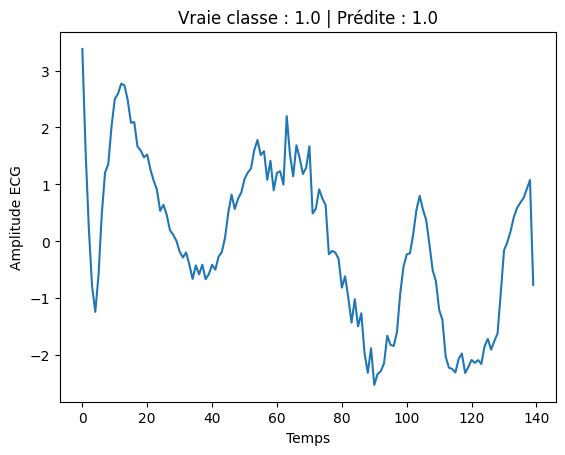

In [12]:
i = 0  # change l'indice pour tester
plt.plot(X_test[i].squeeze())
plt.title(f"Vraie classe : {classes[y_test_idx[i]]} | Prédite : {classes[y_pred[i]]}")
plt.xlabel("Temps")
plt.ylabel("Amplitude ECG")
plt.show()


1. Chargement des données

Les fichiers ECG5000_TRAIN.txt et ECG5000_TEST.txt ont été importés afin de disposer des données d’entraînement et de test.
Chaque ligne correspond à un battement ECG représenté par 140 points.

2. Séparation des entrées et sorties

Le dataset a été divisé en :
X : les valeurs du signal ECG (140 points)
y : les labels indiquant la classe du battement (1 à 5)
Cette séparation permet de préparer les données pour l’apprentissage supervisé.

3. Normalisation des signaux
Une normalisation de type StandardScaler a été appliquée :
Cette étape améliore la stabilité et l’efficacité de l’apprentissage.

4. Mise en forme pour le LSTM
Les données ont été réorganisées sous la forme :
(nombre d’exemples,140,1)
afin de respecter le format requis par les réseaux LSTM (séquences temporelles).

5. Encodage des labels
Les labels ont été convertis en vecteurs one-hot, nécessaires pour une sortie de type softmax dans un problème de classification multi-classe.

6. Construction du modèle
Le modèle utilisé est composé de :
une couche LSTM (64 unités) pour analyser la séquence ECG,
une couche Dense (32 unités, ReLU),
une couche de sortie Dense (softmax) correspondant au nombre de classes.

7. Compilation du modèle
Le modèle a été configuré avec :
Optimiseur : Adam
Fonction de perte : categorical_crossentropy
Métrique : accuracy
Ces choix sont adaptés à une classification multi-classe.

8. Entraînement
Le modèle a été entraîné sur les données normalisées avec :
20 époques,
un batch size de 64,
20% des données utilisées pour la validation.

9. Évaluation

Sur les données de test :
les probabilités de prédiction ont été générées,
les classes finales ont été obtenues via argmax,
les performances ont été analysées à l’aide du rapport de classification et de la matrice de confusion.